# 03 — Dataset Class + DataLoader

โหลดภาพจาก `data/` เข้า PyTorch โดยใช้ `ImageFolder` + `DataLoader`
พร้อม transforms ตามมาตรฐาน MobileNetV2 (224×224, normalize ImageNet)

## 1. Transforms

In [1]:
from torchvision import transforms

# ค่า mean และ std ของ ImageNet — ต้องใช้ค่านี้เสมอเมื่อใช้ MobileNetV2
# เพราะโมเดลถูกเทรนมาด้วยค่านี้
MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

# train_transforms — ใช้ Data Augmentation เพิ่มความหลากหลายให้ข้อมูล
# ช่วยป้องกัน overfitting เมื่อ dataset เล็ก
train_transforms = transforms.Compose([
    # ปรับขนาดภาพเป็น 224×224 ตามที่ MobileNetV2 ต้องการ
    transforms.Resize((224, 224)),
    # พลิกซ้าย-ขวาแบบสุ่ม 50% — สมเหตุสมผลสำหรับผัก
    transforms.RandomHorizontalFlip(),
    # หมุนสุ่ม ±10° — เพราะกล้องตั้งอยู่กับที่ ไม่หมุนมาก
    transforms.RandomRotation(10),
    # แปลงภาพเป็น tensor และปรับค่า pixel จาก 0-255 → 0.0-1.0
    transforms.ToTensor(),
    # normalize ด้วย mean/std ของ ImageNet
    transforms.Normalize(mean=MEAN, std=STD),
])

# val/test transforms — ไม่ augment เพราะต้องการผลที่คงที่สำหรับประเมิน
val_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=MEAN, std=STD),
])

print('transforms พร้อมแล้ว')

transforms พร้อมแล้ว


## 2. Dataset + DataLoader

In [4]:
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader

DATA_DIR   = 'data'
BATCH_SIZE = 32  # ลดเป็น 16 ถ้า GPU out of memory

# ImageFolder อ่านโครงสร้างโฟลเดอร์ data/split/class/ แล้ว label อัตโนมัติ
# โฟลเดอร์ cos → label 0, gok → label 1 (เรียงตามตัวอักษร)
train_dataset = ImageFolder(f'{DATA_DIR}/train', transform=train_transforms)
val_dataset   = ImageFolder(f'{DATA_DIR}/val',   transform=val_transforms)
test_dataset  = ImageFolder(f'{DATA_DIR}/test',  transform=val_transforms)

# DataLoader ห่อ dataset เพื่อดึงข้อมูลเป็น batch
# shuffle=True สำหรับ train เพื่อป้องกันโมเดลจำลำดับ
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset,   batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False)

# แสดง class mapping — ตรวจให้แน่ใจว่า label ถูกต้อง
print(f'class mapping: {train_dataset.class_to_idx}')
print(f'train: {len(train_dataset)} ภาพ, {len(train_loader)} batches')
print(f'val:   {len(val_dataset)} ภาพ, {len(val_loader)} batches')
print(f'test:  {len(test_dataset)} ภาพ, {len(test_loader)} batches')

class mapping: {'cos': 0, 'gok': 1}
train: 2044 ภาพ, 64 batches
val:   408 ภาพ, 13 batches
test:  468 ภาพ, 15 batches


## 3. ตรวจสอบ batch แรก

images shape: torch.Size([32, 3, 224, 224])
labels shape: torch.Size([32])
labels: [1, 0, 0, 0, 1, 1, 1, 0]


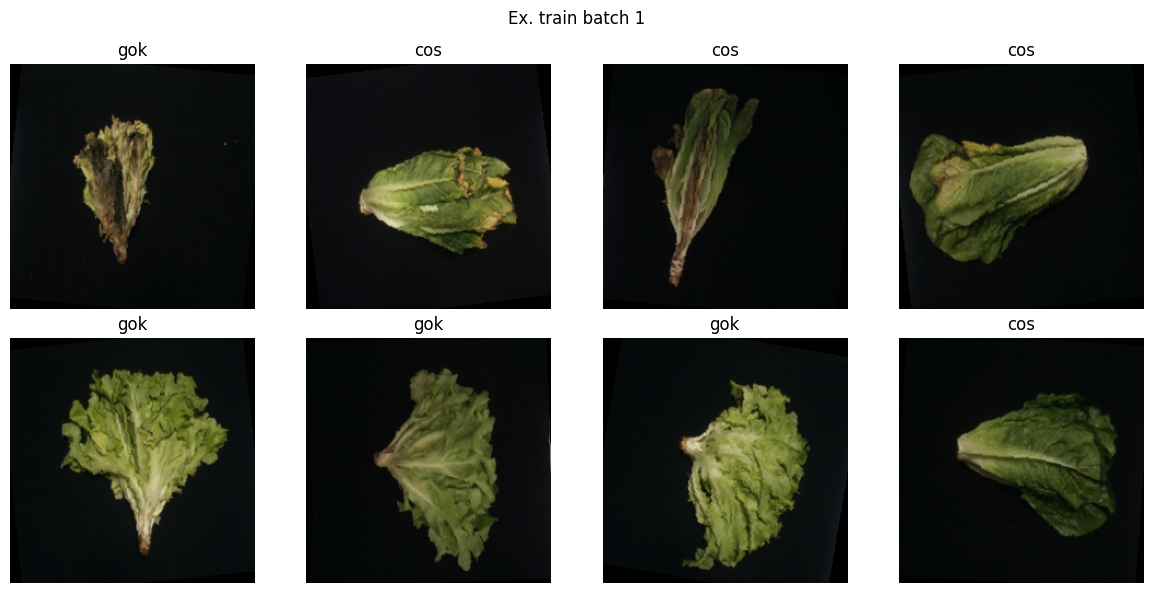

In [5]:
import torch
import matplotlib.pyplot as plt
import numpy as np

# ดึง batch แรกจาก train_loader
images, labels = next(iter(train_loader))

# ตรวจสอบขนาด tensor
print(f'images shape: {images.shape}')  # ควรได้ (32, 3, 224, 224)
print(f'labels shape: {labels.shape}')  # ควรได้ (32,)
print(f'labels: {labels[:8].tolist()}') # ดู label 8 ตัวแรก (0=cos, 1=gok)

# แสดงภาพตัวอย่าง 8 รูปแรก
classes = train_dataset.classes  # ['cos', 'gok']
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for i, ax in enumerate(axes.flat):
    # แปลง tensor กลับเป็นภาพ — ต้อง unnormalize ก่อนแสดง
    img = images[i].numpy().transpose(1, 2, 0)             # NCHW → HWC
    img = img * np.array(STD) + np.array(MEAN)             # unnormalize
    img = np.clip(img, 0, 1)                               # จำกัดค่า 0-1
    ax.imshow(img)
    ax.set_title(classes[labels[i].item()])
    ax.axis('off')

plt.suptitle('Ex. train batch 1')
plt.tight_layout()
plt.show()